# Benchmark Data Analysis

This notebook analyzes the verification benchmark data from `data.json` and calculates median values for:
- `duration_ms`: Total verification duration in milliseconds
- `user_time_secs`: User CPU time in seconds
- `system_time_secs`: System CPU time in seconds

## 1. Load and Parse JSON Data

In [1]:
import json
import statistics
import os

# Path to the data.json file
tpcc_data_file = './tpcc_out/61920/data.json'
social_data_file = './social_out/data.json'
rubis_data_file = './rubis_out/data.json'

# Load the JSON data
with open(tpcc_data_file, 'r') as f:
    tpcc_data = json.load(f)
with open(social_data_file, 'r') as f:
    social_data = json.load(f)
with open(rubis_data_file, 'r') as f:
    rubis_data = json.load(f)

print(f"Loaded data from: {tpcc_data_file, social_data_file, rubis_data_file}")
print(f"Input file: {tpcc_data['input_file'], social_data['input_file'], rubis_data['input_file']}")
print(f"Total verifications: {tpcc_data['summary']['verification_total'], social_data['summary']['verification_total'], rubis_data['summary']['verification_total']}")

# Print following statistics for each dataset
# 1. total verification: length of data['c_edge_verifications']
# 2. passed verification: count in data['c_edge_verifications'][i][result] == "Pass"
# 3. failed verification: count in data['c_edge_verifications'][i][result] == "Error"

topdatasets = {
    "TPCC": tpcc_data,
    "Social": social_data,
    "RUBiS": rubis_data
}
for name, data in topdatasets.items():
    total_verifications = len(data['c_edge_verifications'])
    passed_verifications = sum(1 for v in data['c_edge_verifications'] if v['result'] == "Pass")
    failed_verifications = sum(1 for v in data['c_edge_verifications'] if v['result'] == "Error")
    
    print(f"\n{name} Dataset:")
    print(f"Total Verifications: {total_verifications}")
    print(f"Passed Verifications: {passed_verifications}")
    print(f"Failed Verifications: {failed_verifications}")


Loaded data from: ('./tpcc_out/61920/data.json', './social_out/data.json', './rubis_out/data.json')
Input file: ('tpcc.transact', 'social.transact', 'rubis.transact')
Total verifications: (284, 128, 91)

TPCC Dataset:
Total Verifications: 284
Passed Verifications: 232
Failed Verifications: 52

Social Dataset:
Total Verifications: 128
Passed Verifications: 10
Failed Verifications: 118

RUBiS Dataset:
Total Verifications: 91
Passed Verifications: 12
Failed Verifications: 79


## 2. Extract Duration

In [2]:
# Extract metrics from all verifications
tpcc_duration_ms_values = []
social_duration_ms_values = []
rubis_duration_ms_values = []

def extract_metrics(data, duration_ms_values):
    for verification in data['c_edge_verifications']:
        # Extract duration_ms (always present)
        duration_ms_values.append(verification['duration_ms'])

extract_metrics(tpcc_data, tpcc_duration_ms_values)
extract_metrics(social_data, social_duration_ms_values)
extract_metrics(rubis_data, rubis_duration_ms_values)
# delete the greatest value in tpcc_duration_ms_values to avoid outlier
# tpcc_duration_ms_values.remove(max(tpcc_duration_ms_values))

# divide all duration values by 1000 to convert to seconds
tpcc_duration_ms_values = [x / 1000.0 for x in tpcc_duration_ms_values]
social_duration_ms_values = [x / 1000.0 for x in social_duration_ms_values]
rubis_duration_ms_values = [x / 1000.0 for x in rubis_duration_ms_values]


# Group datasets and their titles for easier processing
datasets = {
    "TPCC": tpcc_duration_ms_values,
    "Social": social_duration_ms_values,
    "RUBiS": rubis_duration_ms_values,
}

## 3. Visualize Distribution

/tmp/ipykernel_3948776/2889386947.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


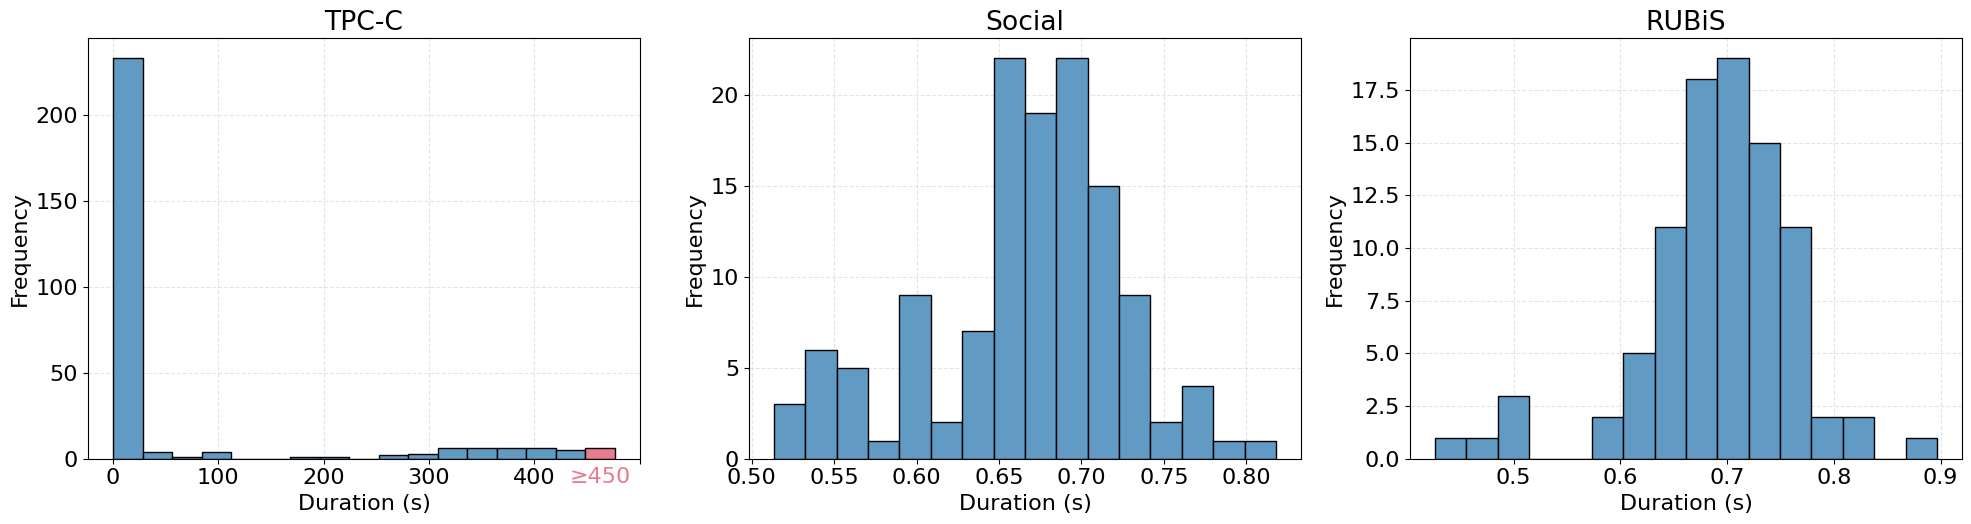

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np

# change to type1/truetype fonts: https://gecco-2025.sigevo.org/Paper-Submission-Instructions
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 16,
})

color_theme = {
    "myblue": (97/255, 154/255, 195/255),
    "myred": (231/255, 124/255, 142/255),
    "mygreen": (97/255, 172/255, 133/255),
    "myorange": (255/255, 153/255, 0/255),
    "edgecolor": "black",
    "gridcolor": "#cccccc",
    "linestyle": "--",
}

# --- Plotting Function ---
def create_histogram(ax, data, title, color_theme, use_log_scale=False, has_outlier=False, normal_range=None):
    """
    Creates a histogram, with an option to aggregate outliers into the last bin,
    which is colored differently and specially labeled.
    """
    # --- 1. Initial Setup and Validation ---
    if data is None or len(data) == 0:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center')
        ax.set_title(title)
        return
    if title is not None:
        ax.set_title(title)
    
    # --- 2. Data and Bin Configuration ---
    data_to_plot = np.copy(data)
    num_bins = 16 # Set the desired number of bins
    bins = num_bins
    xlabel = 'Duration (s)'

    if has_outlier:
        if normal_range is None or len(normal_range) != 2:
            raise ValueError("`normal_range` must be a tuple of (min, max) when has_outlier is True.")
        
        cutoff = normal_range[1]
        plot_end = (normal_range[1] - normal_range[0]) / (num_bins + 1) + normal_range[1]
        # Ensure exactly `num_bins` are created for the range, making the last one the outlier bin.
        # `num_bins + 1` is used to define the correct number of bin edges.
        bins = np.linspace(normal_range[0], plot_end, num_bins + 2)
        data_to_plot[data_to_plot > cutoff] = cutoff

    elif use_log_scale:
        min_val = np.min(data)
        max_val = np.max(data)
        if min_val <= 0: min_val = 1
        bins = np.logspace(np.log10(min_val), np.log10(max_val), 50)
        ax.set_xscale('log')
        xlabel = 'Duration (s) [log scale]'

    # --- 3. Plotting ---
    _, _, patches = ax.hist(data_to_plot, bins=bins, color=color_theme["myblue"], edgecolor=color_theme["edgecolor"])
    ax.grid(True, which="both", ls=color_theme["linestyle"], color=color_theme["gridcolor"], alpha=0.5)
    ax.set_axisbelow(True)

    # --- 4. Final Labeling and Customization ---
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')

    if has_outlier:
        last_patch = patches[-1]

        outlier_face_color = color_theme["myred"]
        last_patch.set_facecolor(outlier_face_color)

        x_pos = last_patch.get_x() + last_patch.get_width() / 2
    
        ax.text(x_pos, -0.02, f'≥{int(cutoff)}', 
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', color=outlier_face_color)

        ticks = ax.get_xticks()
        # print(ticks)
        labels = ax.get_xticklabels()
        for i, tick in enumerate(ticks):
            if tick >= cutoff:
                labels = labels[:i+1]
                ticks = ticks[:i+1]
                labels[i].set_visible(False)
                break
        # ax.set_xticks(ticks)
        ax.set_xticklabels(labels)

# --- Main Execution ---
# 1. Create the combined figure with three subplots in one row
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

create_histogram(axes[0], datasets["TPCC"], "TPC-C", color_theme, has_outlier=True, normal_range=(0, 450.0)) # use_log_scale=True) #has_outlier=True, normal_range=(0, 450.0))
create_histogram(axes[1], datasets["Social"], "Social", color_theme)
create_histogram(axes[2], datasets["RUBiS"], "RUBiS", color_theme)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4. Save figures without title

In [4]:
# Directory to save the figures
output_dir = "histogram_figures_out"
os.makedirs(output_dir, exist_ok=True) # Create the directory if it doesn't exist

print(f"Saving individual plots to '{output_dir}/' directory...")
for name, data in datasets.items():
    # Create a new, single figure for saving
    individual_fig, individual_ax = plt.subplots(figsize=(10, 6))
    if name == "TPCC":
        create_histogram(individual_ax, data, None, color_theme, has_outlier=True, normal_range=(0, 450.0)) # use_log_scale=True) #has_outlier=True, normal_range=(0, 450.0))
    else:
        create_histogram(individual_ax, data, None, color_theme, use_log_scale=False)
    
    # Define the output path and save the figure
    file_path = os.path.join(output_dir, f"{name.lower()}_histogram.pdf")
    individual_fig.savefig(file_path, bbox_inches='tight', format='pdf')
    
    # Close the figure to free up memory
    plt.close(individual_fig)


Saving individual plots to 'histogram_figures_out/' directory...


/tmp/ipykernel_3948776/2889386947.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
